#IMPORT LIBRARIES

In [3]:
# Importing necessary libraries
import os
import numpy as np
import matplotlib.pyplot as plt
import cv2
import seaborn as sns
from sklearn.model_selection import train_test_split
from keras.models import Sequential
from keras.layers import Conv2D, UpSampling2D, Conv2DTranspose, Reshape, MaxPooling2D, Flatten, Dense, Dropout
from keras.models import Model
from keras.layers import Input
import tensorflow as tf 
from keras.layers import concatenate
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, concatenate
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

# Adjusting data directories
data_dir = 'C:/Users/Isaac/BSSD3850/DATASET/train'
healthy_dir = os.path.join(data_dir, 'normal')
pneumonia_dir = os.path.join(data_dir, 'pneumonia')


#LOAD IMAGES AND PREPROCESS THEM

In [4]:
# Function to load and preprocess images
def load_images(directory):
    images = []
    labels = []
    for filename in os.listdir(directory):
        if filename.endswith('.jpeg') or filename.endswith('.jpg'):
            img = cv2.imread(os.path.join(directory, filename))
            img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)  # Convert to grayscale
            img = cv2.resize(img, (150, 150))  # Resize images to a consistent size
            img = np.expand_dims(img, axis=-1)  # Add channel dimension
            images.append(img)
            if directory == healthy_dir:
                labels.append(0)  # Healthy label
            else:
                labels.append(1)  # Pneumonia label
    return images, labels

# Load images and labels
healthy_images, healthy_labels = load_images(healthy_dir)
pneumonia_images, pneumonia_labels = load_images(pneumonia_dir)

# Combine healthy and pneumonia images and labels
X = np.array(healthy_images + pneumonia_images)
y = np.array(healthy_labels + pneumonia_labels)

# Normalize pixel values
X = X / 255.0

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

#ImageDataGenerator

In [5]:
# With data augmentation to prevent overfitting and handling the imbalance in dataset
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Create an ImageDataGenerator object with augmentation configurations
datagen = ImageDataGenerator(
        featurewise_center=False,  # set input mean to 0 over the dataset
        samplewise_center=False,  # set each sample mean to 0
        featurewise_std_normalization=False,  # divide inputs by std of the dataset
        samplewise_std_normalization=False,  # divide each input by its std
        zca_whitening=False,  # apply ZCA whitening
        rotation_range=30,  # randomly rotate images in the range (degrees, 0 to 180)
        zoom_range=0.2,  # Randomly zoom image 
        width_shift_range=0.1,  # randomly shift images horizontally (fraction of total width)
        height_shift_range=0.1,  # randomly shift images vertically (fraction of total height)
        horizontal_flip=True,  # randomly flip images
        vertical_flip=False)  # randomly flip images

# Fit the ImageDataGenerator to the training data
datagen.fit(X_train)

#ENCODER

In [6]:
# Resize the input images to match the output dimensions of the autoencoder
resized_X_train = []
resized_X_test = []
for img in X_train:
    resized_X_train.append(cv2.resize(img, (152, 152)))  # Resize to (152, 152)
for img in X_test:
    resized_X_test.append(cv2.resize(img, (152, 152)))   # Resize to (152, 152)

# Convert lists to numpy arrays
resized_X_train = np.array(resized_X_train)
resized_X_test = np.array(resized_X_test)

# Add channel dimension to the resized images
resized_X_train = np.expand_dims(resized_X_train, axis=-1)
resized_X_test = np.expand_dims(resized_X_test, axis=-1)

print("Shape of resized_X_train:", resized_X_train.shape)
print("Shape of resized_X_test:", resized_X_test.shape)

# Define the input layer with the modified shape
input_img = Input(shape=(152, 152, 1))

# Define the autoencoder architecture
conv1 = Conv2D(32, (3, 3), activation='relu', padding='same')(input_img)
pool1 = MaxPooling2D(pool_size=(2, 2))(conv1)
conv2 = Conv2D(64, (3, 3), activation='relu', padding='same')(pool1)
pool2 = MaxPooling2D(pool_size=(2, 2))(conv2)
conv3 = Conv2D(128, (3, 3), activation='relu', padding='same')(pool2)  
pool3 = MaxPooling2D(pool_size=(2, 2))(conv3)  
up1 = UpSampling2D((2, 2))(pool3)
conv4 = Conv2D(64, (3, 3), activation='relu', padding='same')(up1)
up2 = UpSampling2D((2, 2))(conv4)
conv5 = Conv2D(32, (3, 3), activation='relu', padding='same')(up2)
up3 = UpSampling2D((2, 2))(conv5)
decoded = Conv2D(1, (3, 3), activation='sigmoid', padding='same')(up3)

# Compile the autoencoder
autoencoder = Model(input_img, decoded)
autoencoder.compile(optimizer='adam', loss='binary_crossentropy')

# Train the autoencoder
autoencoder.fit(resized_X_train, resized_X_train, batch_size=32, epochs=10, validation_data=(resized_X_test, resized_X_test))

# Save the trained model
autoencoder.save("autoencoder_model.h5")

# Reconstruct both training and testing data
reconstructed_train = autoencoder.predict(resized_X_train)
reconstructed_test = autoencoder.predict(resized_X_test)

# Calculate reconstruction error
train_errors = np.mean(np.square(resized_X_train - reconstructed_train), axis=(1, 2, 3))
test_errors = np.mean(np.square(resized_X_test - reconstructed_test), axis=(1, 2, 3))

# Set a threshold for classification
threshold = np.mean(train_errors) + 2 * np.std(train_errors)  # Example threshold

# Classify anomalies
train_predictions = train_errors > threshold
test_predictions = test_errors > threshold

# Calculate evaluation metrics
train_accuracy = accuracy_score(y_train, train_predictions)
test_accuracy = accuracy_score(y_test, test_predictions)
train_precision = precision_score(y_train, train_predictions)
test_precision = precision_score(y_test, test_predictions)
train_recall = recall_score(y_train, train_predictions)
test_recall = recall_score(y_test, test_predictions)
train_f1 = f1_score(y_train, train_predictions)
test_f1 = f1_score(y_test, test_predictions)

# Print evaluation metrics
print("Training Accuracy:", train_accuracy)
print("Testing Accuracy:", test_accuracy)
print("Training Precision:", train_precision)
print("Testing Precision:", test_precision)
print("Training Recall:", train_recall)
print("Testing Recall:", test_recall)
print("Training F1 Score:", train_f1)
print("Testing F1 Score:", test_f1)

Shape of resized_X_train: (4172, 152, 152, 1)
Shape of resized_X_test: (1044, 152, 152, 1)
Epoch 1/10
131/131 [==============================] - 176s 1s/step - loss: 0.5857 - val_loss: 0.5690
Epoch 2/10
131/131 [==============================] - 181s 1s/step - loss: 0.5694 - val_loss: 0.5677
Epoch 3/10
131/131 [==============================] - 178s 1s/step - loss: 0.5680 - val_loss: 0.5668
Epoch 4/10
131/131 [==============================] - 182s 1s/step - loss: 0.5673 - val_loss: 0.5662
Epoch 5/10
131/131 [==============================] - 180s 1s/step - loss: 0.5669 - val_loss: 0.5658
Epoch 6/10
131/131 [==============================] - 183s 1s/step - loss: 0.5665 - val_loss: 0.5658
Epoch 7/10
131/131 [==============================] - 181s 1s/step - loss: 0.5661 - val_loss: 0.5653
Epoch 8/10
131/131 [==============================] - 176s 1s/step - loss: 0.5659 - val_loss: 0.5651
Epoch 9/10
131/131 [==============================] - 179s 1s/step - loss: 0.5658 - val_loss: 0.5651


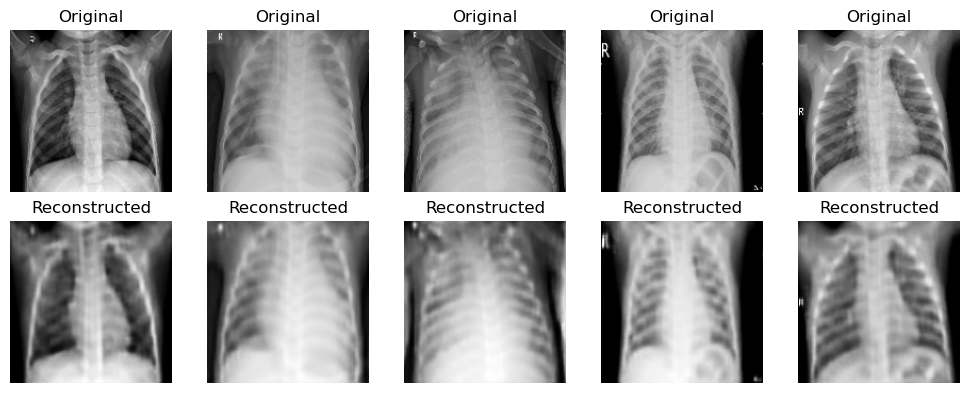

In [7]:
# Select a few samples from the dataset
num_samples = 5
sample_indices = np.random.randint(0, len(resized_X_test), num_samples)

# Plot original and reconstructed images
plt.figure(figsize=(10, 4))
for i, idx in enumerate(sample_indices):
    # Original image
    plt.subplot(2, num_samples, i + 1)
    plt.imshow(np.squeeze(resized_X_test[idx]), cmap='gray')
    plt.title('Original')
    plt.axis('off')

    # Reconstructed image
    plt.subplot(2, num_samples, num_samples + i + 1)
    plt.imshow(np.squeeze(reconstructed_test[idx]), cmap='gray')
    plt.title('Reconstructed')
    plt.axis('off')

plt.tight_layout()
plt.show()

In [8]:
import ipywidgets as widgets
from IPython.display import display
from keras.models import load_model


# Function to preprocess user input
def preprocess_user_input(user_input):
    # Convert the input image to grayscale
    gray_input = cv2.cvtColor(user_input, cv2.COLOR_BGR2GRAY)
    # Resize the grayscale input to (152, 152)
    processed_input = cv2.resize(gray_input, (152, 152))  
    # Add channel dimension
    processed_input = np.expand_dims(processed_input, axis=-1)  
    return processed_input

# Load the trained autoencoder model
autoencoder = load_model('autoencoder_model.h5')

# Define the file upload widget
file_upload = widgets.FileUpload(accept='image/*', multiple=False)

def on_file_upload(change):
    print("File uploaded")  # Add a print statement to check if the function is triggered
    img = cv2.imdecode(np.frombuffer(file_upload.data[-1], np.uint8), -1)
    processed_input = preprocess_user_input(img)
    reconstructed_output = autoencoder.predict(np.array([processed_input]))
    error = np.mean(np.square(processed_input - reconstructed_output))
    threshold = 0.5  # Example threshold, adjust as needed
    if error > threshold:
        print("Anomaly detected!")
    else:
        print("No anomaly detected.")

# Attach the file upload widget to the event handler
file_upload.observe(on_file_upload, names='_counter')

# Display the file upload widget 
display(file_upload)

FileUpload(value=(), accept='image/*', description='Upload')

In [9]:
# Define the button widget
button = widgets.Button(description="Detect Anomaly")

def on_button_click(change):
    # Specify the image directory
    image_path = "CatDog.jpg"# Replace this with the path to your image
    img = cv2.imread(image_path)
    processed_input = preprocess_user_input(img)
    reconstructed_output = autoencoder.predict(np.array([processed_input]))
    error = np.mean(np.square(processed_input - reconstructed_output))
    threshold = 0.5  # Example threshold, adjust as needed
    if error > threshold:
        print("Anomaly detected!")
    else:
        print("No anomaly detected.")

# Attach the button click event handler 
button.on_click(on_button_click)

# Display the button widget
display(button)

Button(description='Detect Anomaly', style=ButtonStyle())

#CNN

In [10]:
# Define the input shape including the batch size dimension
input_shape = (150, 150, 1)

# Define the model
model = Sequential([
    Conv2D(32, (3, 3), activation='relu', input_shape=input_shape),
    MaxPooling2D((2, 2)),
    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),
    Conv2D(128, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),
    Flatten(),
    Dense(64, activation='relu'),
    Dropout(0.5),
    Dense(1, activation='sigmoid')
])

# Display model summary
model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d_6 (Conv2D)           (None, 148, 148, 32)      320       
                                                                 
 max_pooling2d_3 (MaxPooling  (None, 74, 74, 32)       0         
 2D)                                                             
                                                                 
 conv2d_7 (Conv2D)           (None, 72, 72, 64)        18496     
                                                                 
 max_pooling2d_4 (MaxPooling  (None, 36, 36, 64)       0         
 2D)                                                             
                                                                 
 conv2d_8 (Conv2D)           (None, 34, 34, 128)       73856     
                                                                 
 max_pooling2d_5 (MaxPooling  (None, 17, 17, 128)      0

In [11]:
# Compile the model
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])


# Train the model
history = model.fit(X_train.reshape(-1, 150, 150, 1), y_train, epochs=10, batch_size=32, validation_data=(X_test.reshape(-1, 150, 150, 1), y_test))


Epoch 1/10
131/131 [==============================] - 55s 409ms/step - loss: 0.3228 - accuracy: 0.8490 - val_loss: 0.2440 - val_accuracy: 0.9119
Epoch 2/10
131/131 [==============================] - 56s 430ms/step - loss: 0.1842 - accuracy: 0.9338 - val_loss: 0.1048 - val_accuracy: 0.9579
Epoch 3/10
131/131 [==============================] - 54s 414ms/step - loss: 0.1452 - accuracy: 0.9509 - val_loss: 0.1340 - val_accuracy: 0.9511
Epoch 4/10
131/131 [==============================] - 55s 417ms/step - loss: 0.1265 - accuracy: 0.9581 - val_loss: 0.1213 - val_accuracy: 0.9540
Epoch 5/10
131/131 [==============================] - 56s 428ms/step - loss: 0.1085 - accuracy: 0.9662 - val_loss: 0.1132 - val_accuracy: 0.9607
Epoch 6/10
131/131 [==============================] - 54s 411ms/step - loss: 0.0956 - accuracy: 0.9712 - val_loss: 0.0870 - val_accuracy: 0.9693
Epoch 7/10
131/131 [==============================] - 54s 411ms/step - loss: 0.0795 - accuracy: 0.9736 - val_loss: 0.1035 - val_ac

#Visualize Outputs

1/1 [==============================] - 0s 131ms/step


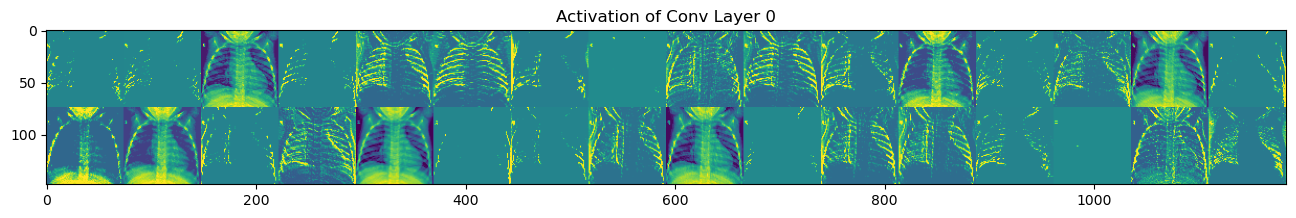

C:\Users\Isaac\anaconda3\envs\Work4\lib\site-packages\ipykernel_launcher.py:16: RuntimeWarning: invalid value encountered in true_divide
  


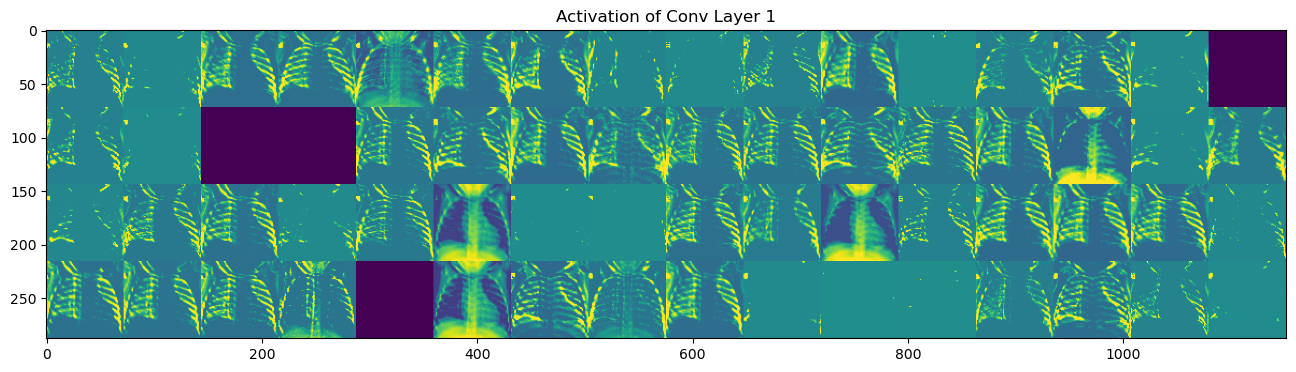

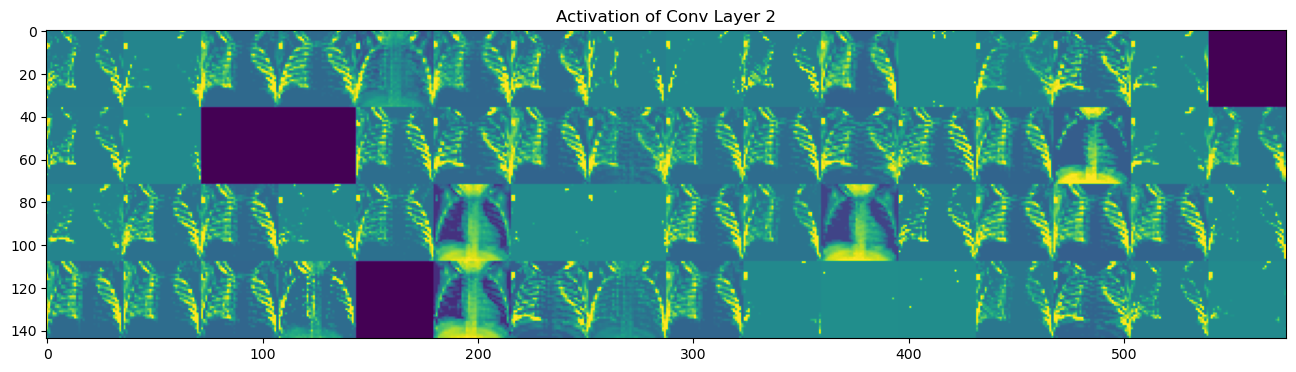

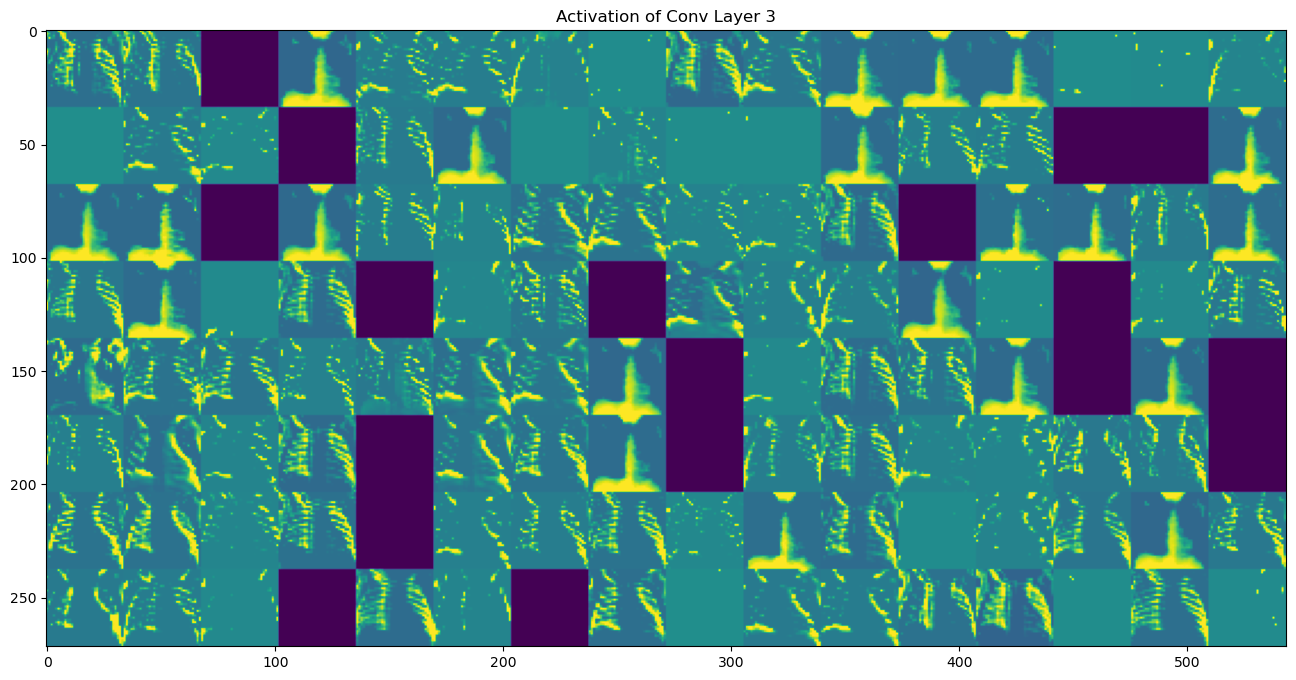

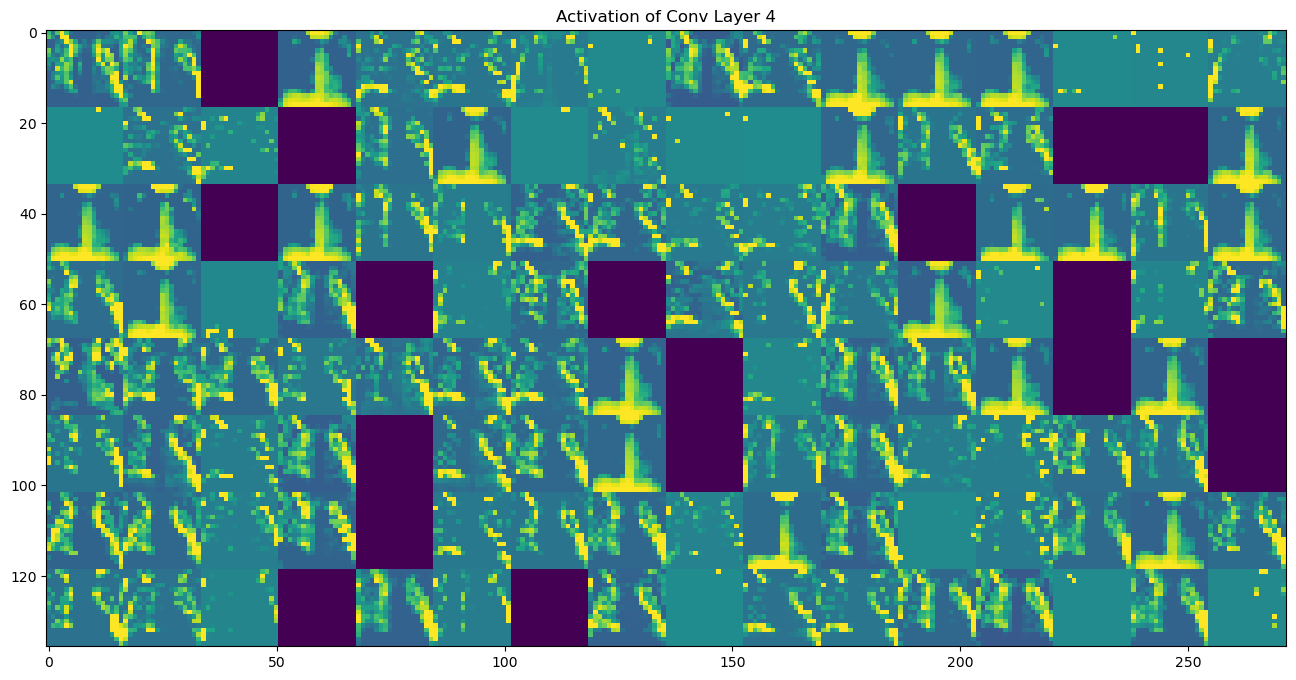

Skipping visualization for layer 5: Shape - (1, 36992)
Skipping visualization for layer 6: Shape - (1, 64)


In [12]:
def visualize_layers(sample_data, model):
    layer_outputs = [layer.output for layer in model.layers[1:] if not isinstance(layer, tf.keras.layers.Dense)]  # Exclude dense layers
    activation_model = tf.keras.models.Model(inputs=model.input, outputs=layer_outputs)
    activations = activation_model.predict(sample_data)

    for i, layer_activation in enumerate(activations):
        if len(layer_activation.shape) == 4:  # Convolutional layers
            n_features = layer_activation.shape[-1]
            size = layer_activation.shape[1]
            n_cols = n_features // 16
            display_grid = np.zeros((size * n_cols, 16 * size))
            for col in range(n_cols):
                for row in range(16):
                    channel_image = layer_activation[0, :, :, col * 16 + row]
                    channel_image -= channel_image.mean()
                    channel_image /= channel_image.std()
                    channel_image *= 64
                    channel_image += 128
                    channel_image = np.clip(channel_image, 0, 255).astype('uint8')
                    display_grid[col * size: (col + 1) * size,
                                 row * size: (row + 1) * size] = channel_image
            scale = 1. / size
            plt.figure(figsize=(scale * display_grid.shape[1],
                                scale * display_grid.shape[0]))
            plt.title(f'Activation of Conv Layer {i}')
            plt.grid(False)
            plt.imshow(display_grid, aspect='auto', cmap='viridis')
            plt.show()
        else:  # Other layers
            print(f"Skipping visualization for layer {i}: Shape - {layer_activation.shape}")
            
# Visualize layers for a sample data
visualize_layers(X_train[:1], model)

33/33 [==============================] - 3s 101ms/step - loss: 0.0965 - accuracy: 0.9646
Test accuracy: 0.9645593762397766


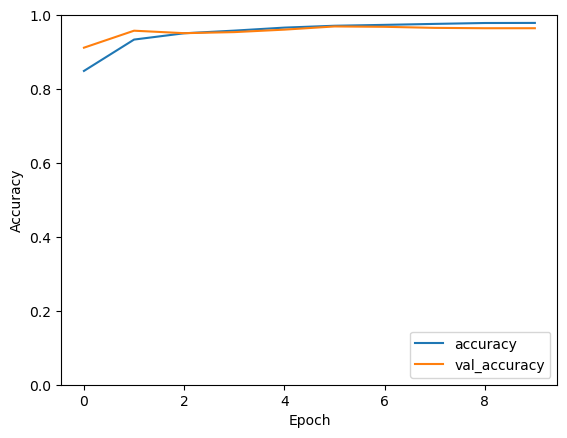

In [13]:
# Evaluate the model
test_loss, test_acc = model.evaluate(X_test.reshape(-1, 150, 150, 1), y_test)
print('Test accuracy:', test_acc)

# Plot training history
plt.plot(history.history['accuracy'], label='accuracy')
plt.plot(history.history['val_accuracy'], label='val_accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.ylim([0, 1])
plt.legend(loc='lower right')
plt.show()

33/33 [==============================] - 4s 105ms/step
Predicted labels: [1 0 1 ... 1 0 1]
True labels: [1 0 1 ... 1 0 1]
Accuracy: 0.9645593869731801
Precision: 0.9838709677419355
Recall: 0.9669749009247027
F1-score: 0.9753497668221185


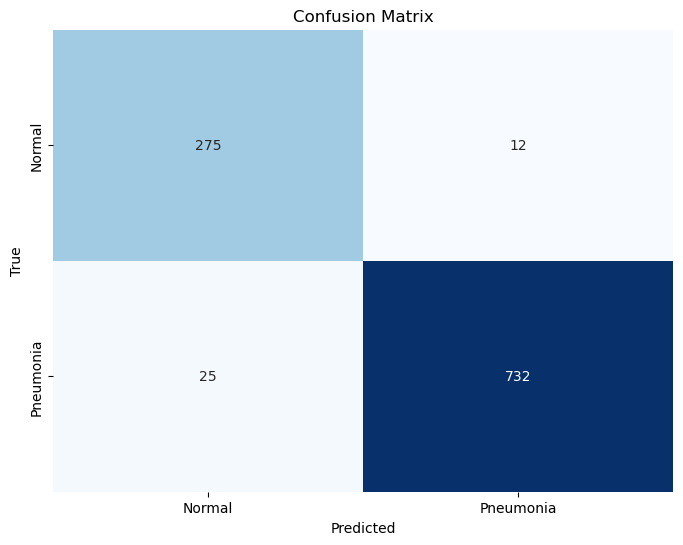

In [14]:
# Calculate predictions for test data
y_pred_prob = model.predict(X_test.reshape(-1, 150, 150, 1))
y_pred = np.round(y_pred_prob).flatten().astype(int)  # Convert probabilities to class labels

print('Predicted labels:', y_pred)
print('True labels:', y_test)

# Calculate accuracy, precision, recall, and F1-score
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print('Accuracy:', accuracy)
print('Precision:', precision)
print('Recall:', recall)
print('F1-score:', f1)

# Plot confusion matrix
conf_matrix = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, cmap='Blues', fmt='g', cbar=False)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.xticks(ticks=[0.5, 1.5], labels=['Normal', 'Pneumonia'])
plt.yticks(ticks=[0.5, 1.5], labels=['Normal', 'Pneumonia'])
plt.title('Confusion Matrix')
plt.show()

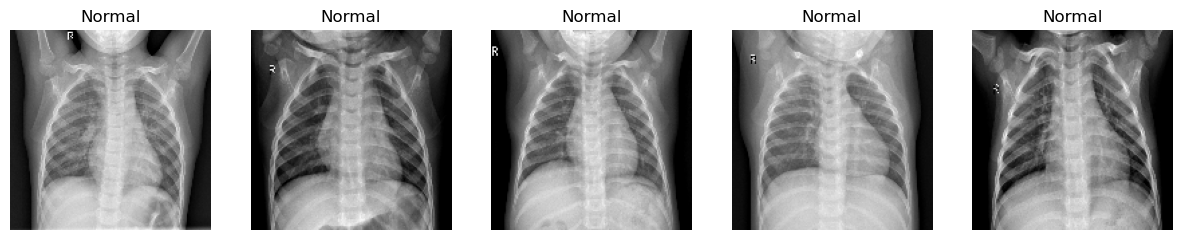

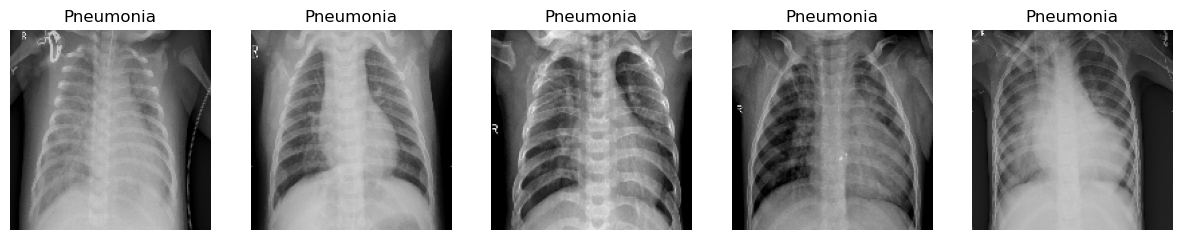

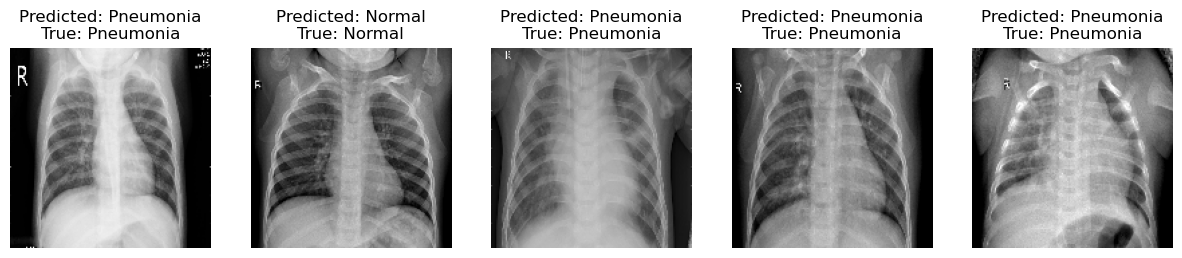

In [15]:
# Visualize some normal X-ray images with labels
plt.figure(figsize=(15, 5))
for i in range(5):
    plt.subplot(1, 5, i+1)
    plt.imshow(healthy_images[i], cmap='gray')
    plt.title('Normal')
    plt.axis('off')
plt.show()

# Visualize some pneumonia X-ray images with labels
plt.figure(figsize=(15, 5))
for i in range(5):
    plt.subplot(1, 5, i+1)
    plt.imshow(pneumonia_images[i], cmap='gray')
    plt.title('Pneumonia')
    plt.axis('off')
plt.show()

# Visualize some test images along with their predicted and true labels
plt.figure(figsize=(15, 5))
for i in range(5):
    plt.subplot(1, 5, i+1)
    plt.imshow(X_test[i], cmap='gray')
    plt.title(f'Predicted: {"Pneumonia" if y_pred[i] == 1 else "Normal"}\nTrue: {"Pneumonia" if y_test[i] == 1 else "Normal"}')
    plt.axis('off')
plt.show()

In [16]:
# Set up test data directories
test_data_dir = 'C:/Users/Isaac/BSSD3850/DATASET/test'
test_healthy_dir = os.path.join(test_data_dir, 'normal')
test_pneumonia_dir = os.path.join(test_data_dir, 'pneumonia')

In [17]:
# Load and preprocess test data
test_healthy_images, test_healthy_labels = load_images(test_healthy_dir)
test_pneumonia_images, test_pneumonia_labels = load_images(test_pneumonia_dir)

# Combine test data
X_test = np.array(test_healthy_images + test_pneumonia_images)
y_test = np.array(test_healthy_labels + test_pneumonia_labels)

# Normalize pixel values
X_test = X_test / 255.0

# Evaluate the model on the test data
test_loss, test_accuracy = model.evaluate(X_test.reshape(-1, 150, 150, 1), y_test)
print('Test Loss:', test_loss)
print('Test Accuracy:', test_accuracy)

20/20 [==============================] - 2s 97ms/step - loss: 0.6508 - accuracy: 0.8269
Test Loss: 0.6507695913314819
Test Accuracy: 0.8269230723381042


20/20 [==============================] - 2s 100ms/step - loss: 0.6508 - accuracy: 0.8269
Test accuracy: 0.8269230723381042


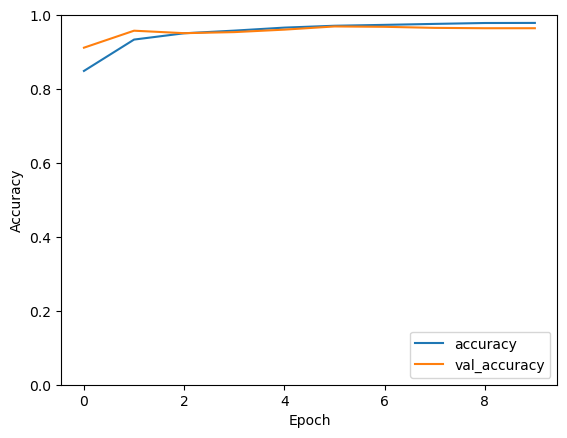

In [18]:
# Evaluate the model
test_loss, test_acc = model.evaluate(X_test.reshape(-1, 150, 150, 1), y_test)
print('Test accuracy:', test_acc)

# Plot training history
plt.plot(history.history['accuracy'], label='accuracy')
plt.plot(history.history['val_accuracy'], label = 'val_accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.ylim([0, 1])
plt.legend(loc='lower right')
plt.show()

20/20 [==============================] - 2s 102ms/step
Predicted labels: [0 1 1 1 0 0 0 1 0 1 0 1 0 0 1 1 1 0 0 0 1 1 0 0 1 0 1 0 1 1 1 1 1 0 1 0 0
 0 1 0 1 0 0 0 1 1 1 1 1 0 0 0 1 0 1 0 1 0 0 1 0 1 1 0 0 0 1 1 1 0 0 0 0 0
 0 0 0 0 0 0 1 0 0 0 0 1 0 0 1 0 0 0 0 0 0 0 0 0 1 0 0 1 0 1 0 0 0 0 0 1 0
 0 0 1 0 1 0 1 1 1 1 1 1 1 1 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 0 0 0 0 1 0 0 1 1 1 1 1 0 0 0 1 1 0 1 1 1 0 1 1 1 1 0 0 0 1 0 1 1 1 1 1
 0 1 0 0 1 1 1 0 1 1 1 1 1 1 0 1 0 1 0 0 1 0 0 0 1 1 0 0 1 0 1 1 1 1 1 1 1
 1 1 0 0 1 1 1 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 0 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 

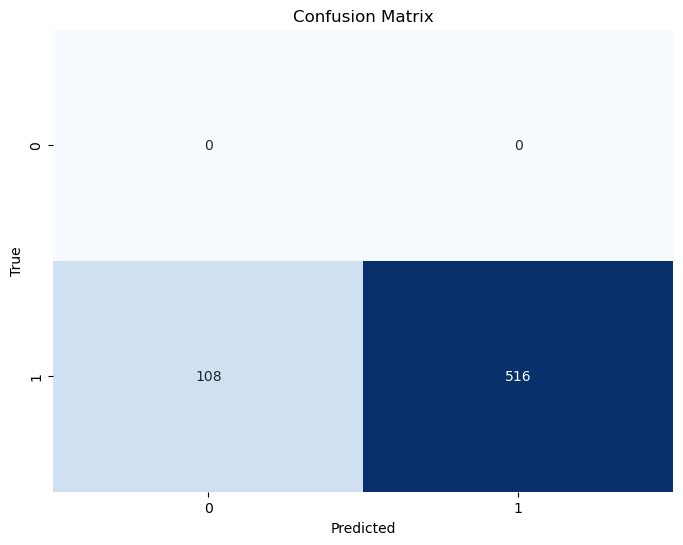

In [19]:
# Calculate predictions for test data
y_pred_prob = model.predict(X_test.reshape(-1, 150, 150, 1))
y_pred = np.round(y_pred_prob).flatten().astype(int)  # Convert probabilities to class labels

print('Predicted labels:', y_pred)
print('True labels:', y_test)


# Calculate accuracy, precision, recall, and F1-score
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print('Accuracy:', accuracy)
print('Precision:', precision)
print('Recall:', recall)
print('F1-score:', f1)

# Plot confusion matrix
conf_matrix = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, cmap='Blues', fmt='g', cbar=False)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()